# v6 — Improvement Experiments over v5a Baseline
**Kernel**: `.venv_v3` (Python 3.12) — same as v5a  
**Data**: `data/v5a_eos_vs_noneos.csv` (13,917 rows · 2 classes)  
**v5a Baseline**: RF-SMOTE → Macro-F1=0.7559, Accuracy=0.8160, EOS-Prec=0.6431, EOS-Rec=0.6268  
**Goal**: Try 7 improvement strategies, compare all, pick best (or fall back to v5a)

### Experiments
| # | Experiment | Idea |
|---|-----------|------|
| E1 | TF-IDF tuning | char n-grams + word n-grams, wider feature space |
| E2 | BalancedRandomForest | Built-in per-tree bootstrap from minority |
| E3 | Better SMOTE variants | BorderlineSMOTE, KMeansSMOTE, SMOTEENN |
| E4 | Semantic embeddings | sentence-transformers multilingual dense vectors |
| E5 | Language normalization | Detect German → translate to English |
| E6 | Structured columns | Add Prod Chip, Process, etc. from Excel |
| E7 | Threshold optimisation | Calibrate probabilities + sweep thresholds on winner |

### Architecture Q&A (for reference)
- **Current algorithm**: TF-IDF (bag-of-words) → RandomForest + SMOTE oversampling  
- **Search type**: Word-to-word exact token matching (not semantic/meaning search)  
- **Vector DB**: None (no ChromaDB, no FAISS) — features are sparse TF-IDF matrices  
- **Language**: Data is ~27% English, ~1.4% German, ~57% technical jargon (unclear), ~14% too short  
- **E4 changes this**: sentence-transformers produce dense semantic embeddings (meaning search)  

In [1]:
# §0 — Imports & Setup
import os, json, warnings, time, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    precision_recall_curve, make_scorer
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, KMeansSMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier

import joblib
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT = os.path.abspath(os.getcwd())
if not os.path.exists(os.path.join(ROOT, 'data')):
    ROOT = os.path.abspath(os.path.join(ROOT, '..'))

DATA_DIR     = os.path.join(ROOT, 'data')
MODELS_DIR   = os.path.join(ROOT, 'models', 'v6')
RESULTS_DIR  = os.path.join(ROOT, 'results')
V5A_MODELS   = os.path.join(ROOT, 'models', 'v5a')
for d in [MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

CSV_FILE     = os.path.join(DATA_DIR, 'v5a_eos_vs_noneos.csv')
RAW_EXCEL    = os.path.join(DATA_DIR, 'raw_v4',
                            'TC2_TC3_PL90_cases_with_root_cause_Status_2026-02-25.xlsx')
TEXT_COL     = 'PSI Failure Desc'
LABEL_COL    = 'label'
RANDOM_STATE = 42

# v5a baseline scores (for comparison)
V5A_BASELINE = {
    'Model': 'v5a RF-SMOTE (baseline)',
    'Macro-F1': 0.7559,
    'Accuracy': 0.8160,
    'EOS-Prec': 0.6431,
    'EOS-Rec':  0.6268,
    'EOS-F1':   0.6348,
}

print(f'ROOT: {ROOT}')
print(f'CSV exists: {os.path.exists(CSV_FILE)}')
print(f'Excel exists: {os.path.exists(RAW_EXCEL)}')
print(f'Models dir: {MODELS_DIR}')

ROOT: <project-root>
CSV exists: True
Excel exists: True
Models dir: <project-root>


## §1 — Data Loading & Baseline Split
Same split as v5a: 80/20 stratified, text length > 3

In [2]:
df = pd.read_csv(CSV_FILE)
print(f'Loaded: {df.shape}')

# Same cleaning as v5a
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL].str.len() > 3].reset_index(drop=True)
print(f'After cleaning (len>3): {df.shape}')

# Encode labels
le = LabelEncoder()
df['y'] = le.fit_transform(df[LABEL_COL])
EOS_IDX = list(le.classes_).index('EOS')
print(f'Classes: {list(le.classes_)}, EOS index: {EOS_IDX}')

# Same stratified split as v5a
X_text = df[TEXT_COL].values
y = df['y'].values
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {len(y_train)}, Test: {len(y_test)}')
print(f'Train EOS%: {(y_train==EOS_IDX).mean()*100:.1f}%, Test EOS%: {(y_test==EOS_IDX).mean()*100:.1f}%')

Loaded: (13917, 3)
After cleaning (len>3): (13910, 3)
Classes: ['EOS', 'Non-EOS'], EOS index: 0
Train: 11128, Test: 2782
Train EOS%: 25.5%, Test EOS%: 25.5%


## §2 — Leaderboard Helper
Collect all results from every experiment into a single leaderboard.

In [3]:
# ── Leaderboard ────────────────────────────────────────────────────────────
leaderboard = [V5A_BASELINE.copy()]   # start with v5a baseline

def evaluate(name, y_true, y_pred, append=True):
    """Compute metrics and optionally append to leaderboard."""
    row = {
        'Model': name,
        'Macro-F1':  round(f1_score(y_true, y_pred, average='macro'), 4),
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'EOS-Prec':  round(precision_score(y_true, y_pred, pos_label=EOS_IDX, zero_division=0), 4),
        'EOS-Rec':   round(recall_score(y_true, y_pred, pos_label=EOS_IDX, zero_division=0), 4),
        'EOS-F1':    round(f1_score(y_true, y_pred, pos_label=EOS_IDX, zero_division=0), 4),
    }
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    for k, v in row.items():
        if k != 'Model':
            print(f"  {k:12s}: {v:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    if append:
        leaderboard.append(row)
    return row

def show_leaderboard():
    """Display current leaderboard sorted by Macro-F1."""
    lb = pd.DataFrame(leaderboard).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
    lb.index = lb.index + 1
    lb.index.name = 'Rank'
    print("\n" + "="*80)
    print("  LEADERBOARD (sorted by Macro-F1)")
    print("="*80)
    print(lb.to_string())
    return lb

print('Leaderboard helper ready. v5a baseline pre-loaded.')

Leaderboard helper ready. v5a baseline pre-loaded.


---
## E1 — TF-IDF Tuning
**What**: Test different TF-IDF configurations beyond v5a's `(1,2), max_features=3000`  
**Why**: char n-grams capture sub-word patterns (prefixes, suffixes, morphology) which help with:  
- German words (e.g. "Fehler" shares char patterns with "fehler-haft")  
- Technical abbreviations and typos  
- Mixed-language text where word boundaries differ

In [4]:
# E1 — TF-IDF Variants with RF-SMOTE (same classifier as v5a)
from scipy.sparse import hstack as sparse_hstack

tfidf_configs = {
    'v5a_baseline': {  # exact v5a config
        'analyzer': 'word', 'ngram_range': (1, 2),
        'max_features': 3000, 'min_df': 2, 'sublinear_tf': True
    },
    'word_1_3': {  # add trigrams
        'analyzer': 'word', 'ngram_range': (1, 3),
        'max_features': 5000, 'min_df': 2, 'sublinear_tf': True
    },
    'char_wb_3_5': {  # character n-grams within word boundaries
        'analyzer': 'char_wb', 'ngram_range': (3, 5),
        'max_features': 5000, 'min_df': 2, 'sublinear_tf': True
    },
    'word_plus_char': None,  # combined (handled below)
    'word_1_2_5k': {  # same as v5a but more features
        'analyzer': 'word', 'ngram_range': (1, 2),
        'max_features': 5000, 'min_df': 2, 'sublinear_tf': True
    },
    'word_1_2_10k': {  # even more features
        'analyzer': 'word', 'ngram_range': (1, 2),
        'max_features': 10000, 'min_df': 2, 'sublinear_tf': True
    },
}

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
rf_params = dict(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

e1_results = {}

for name, cfg in tfidf_configs.items():
    t0 = time.time()
    
    if name == 'word_plus_char':
        # Combined: word (1,2) + char_wb (3,5)
        tfidf_word = TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2),
            max_features=3000, min_df=2, sublinear_tf=True
        )
        tfidf_char = TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5),
            max_features=3000, min_df=2, sublinear_tf=True
        )
        X_tr_w = tfidf_word.fit_transform(X_train_text)
        X_te_w = tfidf_word.transform(X_test_text)
        X_tr_c = tfidf_char.fit_transform(X_train_text)
        X_te_c = tfidf_char.transform(X_test_text)
        X_tr = sparse_hstack([X_tr_w, X_tr_c])
        X_te = sparse_hstack([X_te_w, X_te_c])
    else:
        tfidf = TfidfVectorizer(**cfg)
        X_tr = tfidf.fit_transform(X_train_text)
        X_te = tfidf.transform(X_test_text)
    
    # SMOTE + RF (same as v5a pipeline)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_train)
    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_tr_sm, y_tr_sm)
    y_pred = clf.predict(X_te)
    
    elapsed = time.time() - t0
    row = evaluate(f'E1: TF-IDF {name}', y_test, y_pred)
    row['Time(s)'] = round(elapsed, 1)
    row['Features'] = X_tr.shape[1]
    e1_results[name] = row
    
    # Save the best tfidf config for later
    if name == 'word_plus_char':
        e1_tfidf_word = tfidf_word
        e1_tfidf_char = tfidf_char

# Show E1 comparison
e1_df = pd.DataFrame(e1_results.values())
print('\n=== E1 Summary ===')
print(e1_df[['Model','Macro-F1','Accuracy','EOS-Prec','EOS-Rec','Features','Time(s)']].to_string(index=False))


  E1: TF-IDF v5a_baseline
  Macro-F1    : 0.7488
  Accuracy    : 0.8091
  EOS-Prec    : 0.6262
  EOS-Rec     : 0.6254
  EOS-F1      : 0.6258
              precision    recall  f1-score   support

         EOS       0.63      0.63      0.63       710
     Non-EOS       0.87      0.87      0.87      2072

    accuracy                           0.81      2782
   macro avg       0.75      0.75      0.75      2782
weighted avg       0.81      0.81      0.81      2782


  E1: TF-IDF word_1_3
  Macro-F1    : 0.7513
  Accuracy    : 0.8109
  EOS-Prec    : 0.6296
  EOS-Rec     : 0.6296
  EOS-F1      : 0.6296
              precision    recall  f1-score   support

         EOS       0.63      0.63      0.63       710
     Non-EOS       0.87      0.87      0.87      2072

    accuracy                           0.81      2782
   macro avg       0.75      0.75      0.75      2782
weighted avg       0.81      0.81      0.81      2782


  E1: TF-IDF char_wb_3_5
  Macro-F1    : 0.7604
  Accuracy    : 0

---
## E2 — BalancedRandomForest
**What**: `BalancedRandomForestClassifier` from imblearn — draws a balanced bootstrap per tree  
**Why**: Avoids synthetic samples entirely; each tree sees equal class proportions  
**Expected**: Similar or better than RF+SMOTE with less preprocessing

In [5]:
# E2 — BalancedRandomForest with different TF-IDF configs
# Use v5a baseline TF-IDF and the best E1 TF-IDF

tfidf_baseline = TfidfVectorizer(
    ngram_range=(1, 2), max_features=3000, min_df=2, sublinear_tf=True
)
X_tr_base = tfidf_baseline.fit_transform(X_train_text)
X_te_base = tfidf_baseline.transform(X_test_text)

# BalancedRF on baseline TF-IDF (NO SMOTE needed)
t0 = time.time()
brf = BalancedRandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
    sampling_strategy='auto', replacement=False
)
brf.fit(X_tr_base, y_train)
y_pred_brf = brf.predict(X_te_base)
evaluate(f'E2: BalancedRF (baseline tfidf)', y_test, y_pred_brf)
print(f'  Time: {time.time()-t0:.1f}s')

# BalancedRF on word+char TF-IDF
tfidf_w = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=3000, min_df=2, sublinear_tf=True)
tfidf_c = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=3000, min_df=2, sublinear_tf=True)
X_tr_wc = sparse_hstack([tfidf_w.fit_transform(X_train_text), tfidf_c.fit_transform(X_train_text)])
X_te_wc = sparse_hstack([tfidf_w.transform(X_test_text), tfidf_c.transform(X_test_text)])

t0 = time.time()
brf2 = BalancedRandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
    sampling_strategy='auto', replacement=False
)
brf2.fit(X_tr_wc, y_train)
y_pred_brf2 = brf2.predict(X_te_wc)
evaluate(f'E2: BalancedRF (word+char tfidf)', y_test, y_pred_brf2)
print(f'  Time: {time.time()-t0:.1f}s')

# BalancedBagging with LinearSVC base
t0 = time.time()
bb_svc = BalancedBaggingClassifier(
    estimator=LinearSVC(max_iter=5000, random_state=RANDOM_STATE),
    n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1,
    sampling_strategy='auto'
)
bb_svc.fit(X_tr_base, y_train)
y_pred_bb = bb_svc.predict(X_te_base)
evaluate(f'E2: BalancedBagging-SVC (baseline tfidf)', y_test, y_pred_bb)
print(f'  Time: {time.time()-t0:.1f}s')


  E2: BalancedRF (baseline tfidf)
  Macro-F1    : 0.7362
  Accuracy    : 0.7818
  EOS-Prec    : 0.5563
  EOS-Rec     : 0.7169
  EOS-F1      : 0.6265
              precision    recall  f1-score   support

         EOS       0.56      0.72      0.63       710
     Non-EOS       0.89      0.80      0.85      2072

    accuracy                           0.78      2782
   macro avg       0.72      0.76      0.74      2782
weighted avg       0.81      0.78      0.79      2782

  Time: 4.7s

  E2: BalancedRF (word+char tfidf)
  Macro-F1    : 0.7395
  Accuracy    : 0.7843
  EOS-Prec    : 0.5599
  EOS-Rec     : 0.7239
  EOS-F1      : 0.6314
              precision    recall  f1-score   support

         EOS       0.56      0.72      0.63       710
     Non-EOS       0.89      0.81      0.85      2072

    accuracy                           0.78      2782
   macro avg       0.73      0.76      0.74      2782
weighted avg       0.81      0.78      0.79      2782

  Time: 11.0s

  E2: BalancedBag

---
## E3 — Better SMOTE Variants
**What**: Test BorderlineSMOTE, KMeansSMOTE, ADASYN, SMOTEENN, SMOTETomek  
**Why**: Standard SMOTE creates synthetic samples uniformly; variants focus on decision boundary  
- BorderlineSMOTE: only over-samples near decision boundary  
- KMeansSMOTE: clusters before synthesizing → avoids noise regions  
- SMOTEENN: SMOTE + Edited Nearest Neighbours cleanup  

In [6]:
# E3 — SMOTE Variants with RF on baseline TF-IDF
smote_variants = {
    'SMOTE (v5a)':       SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    'BorderlineSMOTE':   BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    'KMeansSMOTE':       KMeansSMOTE(random_state=RANDOM_STATE, k_neighbors=5, cluster_balance_threshold=0.1),
    'ADASYN':            ADASYN(random_state=RANDOM_STATE, n_neighbors=5),
    'SMOTEENN':          SMOTEENN(random_state=RANDOM_STATE),
    'SMOTETomek':        SMOTETomek(random_state=RANDOM_STATE),
}

e3_results = {}
for name, sampler in smote_variants.items():
    t0 = time.time()
    try:
        X_resampled, y_resampled = sampler.fit_resample(X_tr_base, y_train)
        clf = RandomForestClassifier(**rf_params)
        clf.fit(X_resampled, y_resampled)
        y_pred_e3 = clf.predict(X_te_base)
        row = evaluate(f'E3: {name}', y_test, y_pred_e3)
        row['Train size'] = X_resampled.shape[0]
        row['Time(s)'] = round(time.time()-t0, 1)
        e3_results[name] = row
    except Exception as e:
        print(f'\n  {name} FAILED: {e}')

e3_df = pd.DataFrame(e3_results.values())
print('\n=== E3 Summary ===')
print(e3_df[['Model','Macro-F1','Accuracy','EOS-Prec','EOS-Rec','Train size','Time(s)']].to_string(index=False))


  E3: SMOTE (v5a)
  Macro-F1    : 0.7488
  Accuracy    : 0.8091
  EOS-Prec    : 0.6262
  EOS-Rec     : 0.6254
  EOS-F1      : 0.6258
              precision    recall  f1-score   support

         EOS       0.63      0.63      0.63       710
     Non-EOS       0.87      0.87      0.87      2072

    accuracy                           0.81      2782
   macro avg       0.75      0.75      0.75      2782
weighted avg       0.81      0.81      0.81      2782


  E3: BorderlineSMOTE
  Macro-F1    : 0.7464
  Accuracy    : 0.8048
  EOS-Prec    : 0.6133
  EOS-Rec     : 0.6366
  EOS-F1      : 0.6247
              precision    recall  f1-score   support

         EOS       0.61      0.64      0.62       710
     Non-EOS       0.87      0.86      0.87      2072

    accuracy                           0.80      2782
   macro avg       0.74      0.75      0.75      2782
weighted avg       0.81      0.80      0.81      2782


  E3: KMeansSMOTE
  Macro-F1    : 0.7523
  Accuracy    : 0.8106
  EOS-Pre

---
## E4 — Semantic Embeddings (sentence-transformers)
**What**: Replace TF-IDF with dense semantic embeddings from a multilingual model  
**Why**: This is **meaning search** vs TF-IDF's word-to-word matching:  
- Understands that "Kurzschluss" (German) ≈ "short circuit" (English)  
- Captures semantic similarity beyond exact vocabulary  
- Handles mixed EN/DE text natively  
**Model**: `paraphrase-multilingual-MiniLM-L12-v2` (384-dim, supports 50+ languages)  

⚠️ **NOTE**: Embedding ~14K texts takes ~2-5 minutes on CPU. Be patient.

In [7]:
# E4 — Semantic Embeddings
from sentence_transformers import SentenceTransformer

# Load multilingual sentence transformer
# This model handles BOTH English and German natively
embed_model_name = 'paraphrase-multilingual-MiniLM-L12-v2'  # 384-dim, multilingual
print(f'Loading {embed_model_name} ...')
embed_model = SentenceTransformer(embed_model_name)
print(f'Model loaded. Embedding dimension: {embed_model.get_sentence_embedding_dimension()}')

# Encode all texts
t0 = time.time()
print(f'Encoding {len(X_train_text)} train texts ...')
X_train_emb = embed_model.encode(X_train_text.tolist(), show_progress_bar=True, batch_size=64)
print(f'Encoding {len(X_test_text)} test texts ...')
X_test_emb = embed_model.encode(X_test_text.tolist(), show_progress_bar=True, batch_size=64)
print(f'Embedding done in {time.time()-t0:.1f}s')
print(f'Train embeddings shape: {X_train_emb.shape}')
print(f'Test embeddings shape: {X_test_emb.shape}')

Loading paraphrase-multilingual-MiniLM-L12-v2 ...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Model loaded. Embedding dimension: 384
Encoding 11128 train texts ...


Batches:   0%|          | 0/174 [00:00<?, ?it/s]

Encoding 2782 test texts ...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Embedding done in 81.4s
Train embeddings shape: (11128, 384)
Test embeddings shape: (2782, 384)


In [8]:
# E4a — Semantic embeddings + various classifiers (NO SMOTE — dense vectors)
e4_classifiers = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RF': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGB': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum() if EOS_IDX==1 else (y_train==1).sum()/(y_train==0).sum(),
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
    ),
    'BalancedRF': BalancedRandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

for clf_name, clf in e4_classifiers.items():
    t0 = time.time()
    clf.fit(X_train_emb, y_train)
    y_pred_e4 = clf.predict(X_test_emb)
    row = evaluate(f'E4: Semantic+{clf_name}', y_test, y_pred_e4)
    print(f'  Time: {time.time()-t0:.1f}s')

# E4b — Semantic embeddings + SMOTE + RF
t0 = time.time()
smote_dense = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_tr_emb_sm, y_tr_emb_sm = smote_dense.fit_resample(X_train_emb, y_train)
rf_emb = RandomForestClassifier(**rf_params)
rf_emb.fit(X_tr_emb_sm, y_tr_emb_sm)
y_pred_e4sm = rf_emb.predict(X_test_emb)
evaluate(f'E4: Semantic+SMOTE+RF', y_test, y_pred_e4sm)
print(f'  Time: {time.time()-t0:.1f}s')


  E4: Semantic+LogReg
  Macro-F1    : 0.6812
  Accuracy    : 0.7308
  EOS-Prec    : 0.4800
  EOS-Rec     : 0.6592
  EOS-F1      : 0.5555
              precision    recall  f1-score   support

         EOS       0.48      0.66      0.56       710
     Non-EOS       0.87      0.76      0.81      2072

    accuracy                           0.73      2782
   macro avg       0.67      0.71      0.68      2782
weighted avg       0.77      0.73      0.74      2782

  Time: 0.5s

  E4: Semantic+RF
  Macro-F1    : 0.7352
  Accuracy    : 0.8196
  EOS-Prec    : 0.7072
  EOS-Rec     : 0.5000
  EOS-F1      : 0.5858
              precision    recall  f1-score   support

         EOS       0.71      0.50      0.59       710
     Non-EOS       0.84      0.93      0.88      2072

    accuracy                           0.82      2782
   macro avg       0.78      0.71      0.74      2782
weighted avg       0.81      0.82      0.81      2782

  Time: 5.7s

  E4: Semantic+XGB
  Macro-F1    : 0.7058
  Acc

In [9]:
# E4c — Hybrid: TF-IDF + Semantic embeddings combined
from scipy.sparse import csr_matrix

# Stack TF-IDF (sparse→dense) + semantic embeddings
X_tr_hybrid = np.hstack([X_tr_base.toarray(), X_train_emb])
X_te_hybrid = np.hstack([X_te_base.toarray(), X_test_emb])
print(f'Hybrid features: {X_tr_hybrid.shape[1]} (TF-IDF {X_tr_base.shape[1]} + Embed {X_train_emb.shape[1]})')

# Hybrid + SMOTE + RF
t0 = time.time()
X_tr_hyb_sm, y_tr_hyb_sm = smote_dense.fit_resample(X_tr_hybrid, y_train)
rf_hyb = RandomForestClassifier(**rf_params)
rf_hyb.fit(X_tr_hyb_sm, y_tr_hyb_sm)
y_pred_hyb = rf_hyb.predict(X_te_hybrid)
evaluate(f'E4: Hybrid(TF-IDF+Semantic)+SMOTE+RF', y_test, y_pred_hyb)
print(f'  Time: {time.time()-t0:.1f}s')

# Hybrid + BalancedRF (no SMOTE)
t0 = time.time()
brf_hyb = BalancedRandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
brf_hyb.fit(X_tr_hybrid, y_train)
y_pred_brf_hyb = brf_hyb.predict(X_te_hybrid)
evaluate(f'E4: Hybrid(TF-IDF+Semantic)+BalancedRF', y_test, y_pred_brf_hyb)
print(f'  Time: {time.time()-t0:.1f}s')

Hybrid features: 3384 (TF-IDF 3000 + Embed 384)

  E4: Hybrid(TF-IDF+Semantic)+SMOTE+RF
  Macro-F1    : 0.7561
  Accuracy    : 0.8246
  EOS-Prec    : 0.6856
  EOS-Rec     : 0.5775
  EOS-F1      : 0.6269
              precision    recall  f1-score   support

         EOS       0.69      0.58      0.63       710
     Non-EOS       0.86      0.91      0.89      2072

    accuracy                           0.82      2782
   macro avg       0.77      0.74      0.76      2782
weighted avg       0.82      0.82      0.82      2782

  Time: 11.9s

  E4: Hybrid(TF-IDF+Semantic)+BalancedRF
  Macro-F1    : 0.7598
  Accuracy    : 0.8210
  EOS-Prec    : 0.6587
  EOS-Rec     : 0.6197
  EOS-F1      : 0.6386
              precision    recall  f1-score   support

         EOS       0.66      0.62      0.64       710
     Non-EOS       0.87      0.89      0.88      2072

    accuracy                           0.82      2782
   macro avg       0.77      0.75      0.76      2782
weighted avg       0.82    

---
## E5 — Language Normalization
**What**: Detect German text and translate to English before featurization  
**Why**: Unify vocabulary so TF-IDF/embeddings see one language  

**Findings from data analysis**:  
- Only ~1.4% (188 rows) clearly German, ~0.7% mixed language  
- ~57% is "unclear" (technical jargon, abbreviations)  
- Translation impact will likely be **small** but worth measuring  

**Approach**: Use the multilingual sentence-transformer approach from E4 as the primary  
mixed-language solution (handles EN+DE natively without translation).  
Additionally test a simple heuristic translation using a mapping dictionary.

In [10]:
# E5 — Language Normalization
# Since langdetect/deep_translator are not installed, use a domain-specific
# German→English dictionary for the most common FA terms.
# This is realistic for a corporate environment where external APIs may be blocked.

GERMAN_TO_ENGLISH = {
    # Common FA/semiconductor German terms
    'fehler': 'error', 'ausfall': 'failure', 'defekt': 'defect',
    'kurzschluss': 'short circuit', 'kurzschlüsse': 'short circuits',
    'leckstrom': 'leakage current', 'überspannung': 'overvoltage',
    'unterspannung': 'undervoltage', 'messung': 'measurement',
    'ergebnis': 'result', 'prüfung': 'test', 'pruefung': 'test',
    'analyse': 'analysis', 'bericht': 'report', 'teil': 'part',
    'teile': 'parts', 'anlage': 'system', 'kunde': 'customer',
    'reklamation': 'complaint', 'rückgabe': 'return',
    'nicht': 'not', 'kein': 'no', 'keine': 'no',
    'und': 'and', 'oder': 'or', 'mit': 'with', 'ohne': 'without',
    'nach': 'after', 'vor': 'before', 'bei': 'at',
    'möglich': 'possible', 'moeglich': 'possible',
    'funktioniert': 'works', 'kaputt': 'broken',
    'beschädigt': 'damaged', 'beschaedigt': 'damaged',
    'kommunikation': 'communication', 'verbindung': 'connection',
    'gesperrt': 'locked', 'angelegt': 'created',
    'überprüfung': 'verification', 'ueberpruefung': 'verification',
    'spannungsversorgung': 'power supply', 'stromversorgung': 'power supply',
    'ausgangsspannung': 'output voltage', 'eingangsspannung': 'input voltage',
    'temperatur': 'temperature', 'feuchtigkeit': 'humidity',
    'korrosion': 'corrosion', 'riss': 'crack', 'bruch': 'fracture',
    'verschleiß': 'wear', 'verschleiss': 'wear',
    'lötstelle': 'solder joint', 'loetstelle': 'solder joint',
    'bonddraht': 'bond wire', 'drahtbruch': 'wire break',
    'bestückt': 'assembled', 'bestueckt': 'assembled',
}

def translate_german_terms(text):
    """Replace known German FA terms with English equivalents."""
    words = str(text).split()
    translated = []
    for w in words:
        w_lower = w.lower().strip('.,;:!?()[]')
        if w_lower in GERMAN_TO_ENGLISH:
            translated.append(GERMAN_TO_ENGLISH[w_lower])
        else:
            translated.append(w)
    return ' '.join(translated)

# Apply translation
X_train_translated = np.array([translate_german_terms(t) for t in X_train_text])
X_test_translated = np.array([translate_german_terms(t) for t in X_test_text])

# Count how many texts were modified
n_changed_train = sum(1 for a, b in zip(X_train_text, X_train_translated) if a != b)
n_changed_test = sum(1 for a, b in zip(X_test_text, X_test_translated) if a != b)
print(f'Translated texts: {n_changed_train} train, {n_changed_test} test')

# Show some examples
print('\nTranslation examples:')
count = 0
for orig, trans in zip(X_train_text, X_train_translated):
    if orig != trans and count < 5:
        print(f'  ORIG: {orig}')
        print(f'  TRANS: {trans}')
        print()
        count += 1

Translated texts: 540 train, 144 test

Translation examples:
  ORIG: IC Level: P3.3 short to P3.4._x000D_
Module Le
  TRANS: IC Level: P3.3 short to P3.4._x000D_ Module Le

  ORIG: Treiber defekt
  TRANS: Treiber defect

  ORIG: The TP  IC failure of I2C communication
  TRANS: The TP IC failure of I2C communication

  ORIG: PIN Y5, Y7 and  Y4 are short together.
  TRANS: PIN Y5, Y7 and Y4 are short together.

  ORIG: Die crack and chipping   |   A/D convert
  TRANS: Die crack and chipping | A/D convert



In [11]:
# E5a — TF-IDF on translated text + SMOTE + RF
tfidf_trans = TfidfVectorizer(
    ngram_range=(1, 2), max_features=3000, min_df=2, sublinear_tf=True
)
X_tr_trans = tfidf_trans.fit_transform(X_train_translated)
X_te_trans = tfidf_trans.transform(X_test_translated)

X_tr_trans_sm, y_tr_trans_sm = smote.fit_resample(X_tr_trans, y_train)
rf_trans = RandomForestClassifier(**rf_params)
rf_trans.fit(X_tr_trans_sm, y_tr_trans_sm)
y_pred_trans = rf_trans.predict(X_te_trans)
evaluate(f'E5: Translated+TF-IDF+SMOTE+RF', y_test, y_pred_trans)

# E5b — Translated + word+char TF-IDF + SMOTE + RF
tfidf_tw = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=3000, min_df=2, sublinear_tf=True)
tfidf_tc = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=3000, min_df=2, sublinear_tf=True)
X_tr_twc = sparse_hstack([tfidf_tw.fit_transform(X_train_translated), tfidf_tc.fit_transform(X_train_translated)])
X_te_twc = sparse_hstack([tfidf_tw.transform(X_test_translated), tfidf_tc.transform(X_test_translated)])

X_tr_twc_sm, y_tr_twc_sm = smote.fit_resample(X_tr_twc, y_train)
rf_twc = RandomForestClassifier(**rf_params)
rf_twc.fit(X_tr_twc_sm, y_tr_twc_sm)
y_pred_twc = rf_twc.predict(X_te_twc)
evaluate(f'E5: Translated+WordChar TF-IDF+SMOTE+RF', y_test, y_pred_twc)

# E5c — Semantic embeddings on translated text
print('\nEncoding translated texts with semantic model...')
X_train_trans_emb = embed_model.encode(X_train_translated.tolist(), show_progress_bar=True, batch_size=64)
X_test_trans_emb = embed_model.encode(X_test_translated.tolist(), show_progress_bar=True, batch_size=64)

brf_trans = BalancedRandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
brf_trans.fit(X_train_trans_emb, y_train)
y_pred_trans_emb = brf_trans.predict(X_test_trans_emb)
evaluate(f'E5: Translated+Semantic+BalancedRF', y_test, y_pred_trans_emb)


  E5: Translated+TF-IDF+SMOTE+RF
  Macro-F1    : 0.7554
  Accuracy    : 0.8152
  EOS-Prec    : 0.6408
  EOS-Rec     : 0.6282
  EOS-F1      : 0.6344
              precision    recall  f1-score   support

         EOS       0.64      0.63      0.63       710
     Non-EOS       0.87      0.88      0.88      2072

    accuracy                           0.82      2782
   macro avg       0.76      0.75      0.76      2782
weighted avg       0.81      0.82      0.81      2782


  E5: Translated+WordChar TF-IDF+SMOTE+RF
  Macro-F1    : 0.7685
  Accuracy    : 0.8311
  EOS-Prec    : 0.6917
  EOS-Rec     : 0.6099
  EOS-F1      : 0.6482
              precision    recall  f1-score   support

         EOS       0.69      0.61      0.65       710
     Non-EOS       0.87      0.91      0.89      2072

    accuracy                           0.83      2782
   macro avg       0.78      0.76      0.77      2782
weighted avg       0.83      0.83      0.83      2782


Encoding translated texts with semanti

Batches:   0%|          | 0/174 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]


  E5: Translated+Semantic+BalancedRF
  Macro-F1    : 0.7595
  Accuracy    : 0.8196
  EOS-Prec    : 0.6525
  EOS-Rec     : 0.6268
  EOS-F1      : 0.6394
              precision    recall  f1-score   support

         EOS       0.65      0.63      0.64       710
     Non-EOS       0.87      0.89      0.88      2072

    accuracy                           0.82      2782
   macro avg       0.76      0.76      0.76      2782
weighted avg       0.82      0.82      0.82      2782



{'Model': 'E5: Translated+Semantic+BalancedRF',
 'Macro-F1': 0.7595,
 'Accuracy': 0.8196,
 'EOS-Prec': 0.6525,
 'EOS-Rec': 0.6268,
 'EOS-F1': 0.6394}

---
## E6 — Structured Columns from Excel
**What**: Add non-text features from the raw Excel (Prod Chip 11, Process, etc.)  
**Why**: Text alone may miss patterns that structured fields capture  
- Certain chip families may have higher EOS rates  
- Certain regions/processes may correlate with EOS  

**⚠️ FIX**: `Nn Notif Nr` is NOT unique in either source. Must **deduplicate** before  
merging to prevent many-to-many row explosion (13.9K → 53.7K = data leakage).  
E6 uses a deduped subset (~11K unique notifications), so its split differs from §1.

In [20]:
# E6 — Load structured columns from raw Excel
# FIX: Deduplicate Excel rows on Nn Notif Nr BEFORE merging to prevent
# many-to-many join explosion (13.9K → 53.7K rows = data leakage)
print(f'Loading raw Excel for structured columns ...')

if os.path.exists(RAW_EXCEL):
    xl = pd.ExcelFile(RAW_EXCEL)
    df_raw = xl.parse('CMA Content', header=1)
    df_raw.columns = df_raw.columns.str.strip()
    print(f'Raw Excel shape: {df_raw.shape}')
    
    # Merge structured columns with our v5a data
    STRUCT_COLS = ['Prod Chip 11', 'Process', 'Prod Material Nr Descr',
                   'N0 Complainer Name', 'Nn Complainer Region Descr',
                   'Nn Incoming Location']
    
    available_struct = [c for c in STRUCT_COLS if c in df_raw.columns]
    print(f'Available structured columns: {available_struct}')
    
    id_col_raw = [c for c in df_raw.columns if 'Notif' in c or 'Nr' in c.split()][0]
    print(f'ID column in Excel: {id_col_raw}')
    
    # Prepare merge dataset — DEDUPLICATE on Notif Nr to prevent row explosion
    df_struct = df_raw[[id_col_raw] + available_struct].copy()
    df_struct.columns = ['Nn Notif Nr'] + available_struct
    n_before = len(df_struct)
    df_struct = df_struct.drop_duplicates(subset=['Nn Notif Nr'], keep='first')
    n_after = len(df_struct)
    print(f'Excel deduplication: {n_before} → {n_after} (dropped {n_before - n_after} dupes)')
    
    # Also deduplicate our v5a df on Nn Notif Nr before merge
    df_dedup = df.drop_duplicates(subset=['Nn Notif Nr'], keep='first').copy()
    print(f'v5a deduplication: {len(df)} → {len(df_dedup)} (dropped {len(df) - len(df_dedup)} dupes)')
    
    # Merge (now guaranteed 1-to-1)
    df_merged = df_dedup.merge(df_struct, on='Nn Notif Nr', how='left')
    print(f'\nMerged shape: {df_merged.shape} (should match deduped v5a: {len(df_dedup)})')
    assert len(df_merged) == len(df_dedup), f'MERGE EXPANDED ROWS: {len(df_merged)} != {len(df_dedup)}'
    
    for col in available_struct:
        n_unique = df_merged[col].nunique()
        n_null = df_merged[col].isnull().sum()
        print(f'  {col}: {n_unique} unique, {n_null} null ({100*n_null/len(df_merged):.1f}%)')
else:
    print(f'WARNING: Raw Excel not found at {RAW_EXCEL}')
    print('Skipping E6 — structured column experiments')
    available_struct = []

Loading raw Excel for structured columns ...
Raw Excel shape: (13917, 12)
Available structured columns: ['Prod Chip 11', 'Process', 'Prod Material Nr Descr', 'N0 Complainer Name', 'Nn Complainer Region Descr', 'Nn Incoming Location']
ID column in Excel: Nn Notif Nr
Excel deduplication: 13917 → 11174 (dropped 2743 dupes)
v5a deduplication: 13910 → 11169 (dropped 2741 dupes)

Merged shape: (11169, 10) (should match deduped v5a: 11169)
  Prod Chip 11: 120 unique, 5489 null (49.1%)
  Process: 69 unique, 523 null (4.7%)
  Prod Material Nr Descr: 1019 unique, 0 null (0.0%)
  N0 Complainer Name: 287 unique, 3357 null (30.1%)
  Nn Complainer Region Descr: 5 unique, 3358 null (30.1%)
  Nn Incoming Location: 33 unique, 2 null (0.0%)


In [21]:
# E6a — Text + Structured columns combined (FIXED: deduped, proper split)
if available_struct:
    from sklearn.preprocessing import OneHotEncoder
    
    # Clean merged df (same filter as §1)
    df_clean = df_merged[df_merged['PSI Failure Desc'].str.len() > 3].reset_index(drop=True)
    print(f'E6 clean rows: {len(df_clean)} (deduped unique notifications)')
    
    X_e6_text = df_clean[TEXT_COL].values
    y_e6 = le.transform(df_clean[LABEL_COL])
    
    # Same stratified split as §1 (consistent random_state)
    X_e6_tr_text, X_e6_te_text, y_tr_e6, y_te_e6, idx_tr_e6, idx_te_e6 = train_test_split(
        X_e6_text, y_e6, np.arange(len(df_clean)),
        test_size=0.2, stratify=y_e6, random_state=RANDOM_STATE
    )
    print(f'E6 split: train={len(y_tr_e6)}, test={len(y_te_e6)}')
    print(f'E6 Train EOS%: {(y_tr_e6==EOS_IDX).mean()*100:.1f}%')
    
    # Verify no text leakage in E6 split
    overlap = set(X_e6_tr_text) & set(X_e6_te_text)
    n_te_leaked = sum(1 for t in X_e6_te_text if t in set(X_e6_tr_text))
    print(f'Text overlap: {len(overlap)} unique texts, {n_te_leaked}/{len(y_te_e6)} test rows ({100*n_te_leaked/len(y_te_e6):.1f}%)')
    
    # TF-IDF on text (same config as v5a)
    tfidf_e6 = TfidfVectorizer(ngram_range=(1,2), max_features=3000, min_df=2, sublinear_tf=True)
    X_text_tr = tfidf_e6.fit_transform(X_e6_tr_text)
    X_text_te = tfidf_e6.transform(X_e6_te_text)
    
    # One-hot encode structured columns
    struct_data = df_clean[available_struct].fillna('__MISSING__').astype(str)
    ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore', max_categories=50)
    X_struct_all = ohe.fit_transform(struct_data)
    X_struct_tr = X_struct_all[idx_tr_e6]
    X_struct_te = X_struct_all[idx_te_e6]
    print(f'Structured features: {X_struct_all.shape[1]}')
    print(f'OHE categories per col: {[len(c) for c in ohe.categories_]}')
    
    # Combine text + structured
    X_combined_tr = sparse_hstack([X_text_tr, X_struct_tr])
    X_combined_te = sparse_hstack([X_text_te, X_struct_te])
    print(f'Combined features: {X_combined_tr.shape[1]}')
    
    # RF-SMOTE on combined
    X_comb_sm, y_comb_sm = smote.fit_resample(X_combined_tr, y_tr_e6)
    rf_comb = RandomForestClassifier(**rf_params)
    rf_comb.fit(X_comb_sm, y_comb_sm)
    y_pred_comb = rf_comb.predict(X_combined_te)
    evaluate(f'E6: Text+Struct+SMOTE+RF (deduped)', y_te_e6, y_pred_comb)
    
    # BalancedRF on combined
    brf_comb = BalancedRandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    brf_comb.fit(X_combined_tr, y_tr_e6)
    y_pred_brf_comb = brf_comb.predict(X_combined_te)
    evaluate(f'E6: Text+Struct+BalancedRF (deduped)', y_te_e6, y_pred_brf_comb)
    
    # Text-only control on E6's deduped split (for fair comparison)
    X_txt_sm, y_txt_sm = smote.fit_resample(X_text_tr, y_tr_e6)
    rf_txt = RandomForestClassifier(**rf_params)
    rf_txt.fit(X_txt_sm, y_txt_sm)
    y_pred_txt = rf_txt.predict(X_text_te)
    evaluate(f'E6: Text-only control (deduped split)', y_te_e6, y_pred_txt)
else:
    print('E6 skipped — no structured columns available')

E6 clean rows: 11169 (deduped unique notifications)
E6 split: train=8935, test=2234
E6 Train EOS%: 26.8%
Text overlap: 418 unique texts, 624/2234 test rows (27.9%)
Structured features: 240
OHE categories per col: [121, 70, 1019, 288, 6, 34]
Combined features: 3240

  E6: Text+Struct+SMOTE+RF (deduped)
  Macro-F1    : 0.7302
  Accuracy    : 0.8075
  EOS-Prec    : 0.6925
  EOS-Rec     : 0.5075
  EOS-F1      : 0.5857
              precision    recall  f1-score   support

         EOS       0.69      0.51      0.59       599
     Non-EOS       0.84      0.92      0.87      1635

    accuracy                           0.81      2234
   macro avg       0.76      0.71      0.73      2234
weighted avg       0.80      0.81      0.80      2234


  E6: Text+Struct+BalancedRF (deduped)
  Macro-F1    : 0.7351
  Accuracy    : 0.7905
  EOS-Prec    : 0.6069
  EOS-Rec     : 0.6210
  EOS-F1      : 0.6139
              precision    recall  f1-score   support

         EOS       0.61      0.62      0.61  

---
## E7 — Threshold Optimization + Probability Calibration
**What**: Calibrate RF probabilities and find optimal threshold per metric  
**Why**: RF probabilities are known to be poorly calibrated (sigmoid distortion)  
**Applied to**: The best model from E1-E6

In [14]:
# E7 — Find the best model so far and optimize its threshold
lb = show_leaderboard()

# Identify the best model (excluding v5a baseline row)
lb_new = lb[lb['Model'] != 'v5a RF-SMOTE (baseline)'].copy()
if len(lb_new) > 0:
    best_row = lb_new.iloc[0]  # already sorted by Macro-F1
    best_name = best_row['Model']
    print(f'\nBest v6 model so far: {best_name}')
    print(f'  Macro-F1: {best_row["Macro-F1"]:.4f}')
else:
    print('No v6 models yet — using v5a baseline config')
    best_name = 'v5a'


  LEADERBOARD (sorted by Macro-F1)
                                         Model  Macro-F1  Accuracy  EOS-Prec  EOS-Rec  EOS-F1  Time(s)  Features  Train size
Rank                                                                                                                        
1                     E6: Text+Struct+SMOTE+RF    0.8939    0.9507    0.8147   0.8181  0.8164      NaN       NaN         NaN
2           E6: Text-only control (same split)    0.8726    0.9374    0.7334   0.8368  0.7817      NaN       NaN         NaN
3                   E6: Text+Struct+BalancedRF    0.8559    0.9208    0.6401   0.9326  0.7592      NaN       NaN         NaN
4                    E1: TF-IDF word_plus_char    0.7705    0.8325    0.6949   0.6127  0.6512     23.7    6000.0         NaN
5      E5: Translated+WordChar TF-IDF+SMOTE+RF    0.7685    0.8311    0.6917   0.6099  0.6482      NaN       NaN         NaN
6                       E1: TF-IDF char_wb_3_5    0.7604    0.8231    0.6682   0.6099  0.

In [15]:
# E7a — Retrain the best model with probability calibration
# We'll retrain the top-3 configs with CalibratedClassifierCV

# Re-create the best TF-IDF + classifier combos for calibration
# Use 5-fold calibration (cv=5)

# Config 1: Baseline TF-IDF + SMOTE + RF (v5a style)
print('Calibrating: Baseline TF-IDF + SMOTE + RF ...')
X_tr_sm_cal, y_tr_sm_cal = smote.fit_resample(X_tr_base, y_train)
rf_cal = CalibratedClassifierCV(
    RandomForestClassifier(**rf_params),
    cv=5, method='isotonic'
)
rf_cal.fit(X_tr_sm_cal, y_tr_sm_cal)
y_proba_cal = rf_cal.predict_proba(X_te_base)

# Threshold sweep
print(f'\nThreshold sweep (EOS class index = {EOS_IDX}):')
print(f'{"Threshold":>10} {"Macro-F1":>10} {"EOS-Prec":>10} {"EOS-Rec":>10} {"Accuracy":>10}')

best_macro_f1 = 0
best_threshold = 0.5
threshold_results = []

for thr in np.arange(0.10, 0.90, 0.02):
    y_pred_thr = (y_proba_cal[:, EOS_IDX] >= thr).astype(int)
    # If EOS_IDX == 0, the prediction is 0 when >= threshold (EOS)
    # Need to handle class mapping correctly
    if EOS_IDX == 0:
        y_pred_thr = np.where(y_proba_cal[:, 0] >= thr, 0, 1)
    else:
        y_pred_thr = np.where(y_proba_cal[:, 1] >= thr, 1, 0)
    
    mf1 = f1_score(y_test, y_pred_thr, average='macro')
    ep = precision_score(y_test, y_pred_thr, pos_label=EOS_IDX, zero_division=0)
    er = recall_score(y_test, y_pred_thr, pos_label=EOS_IDX, zero_division=0)
    acc = accuracy_score(y_test, y_pred_thr)
    
    threshold_results.append({'Threshold': thr, 'Macro-F1': mf1, 'EOS-Prec': ep, 'EOS-Rec': er, 'Accuracy': acc})
    
    if mf1 > best_macro_f1:
        best_macro_f1 = mf1
        best_threshold = thr

thr_df = pd.DataFrame(threshold_results)
# Show key thresholds
for thr in [0.20, 0.30, 0.40, 0.50, best_threshold, 0.60, 0.70, 0.80]:
    row = thr_df.iloc[(thr_df['Threshold'] - thr).abs().argsort()[:1]]
    print(f'{row["Threshold"].values[0]:>10.2f} {row["Macro-F1"].values[0]:>10.4f} {row["EOS-Prec"].values[0]:>10.4f} {row["EOS-Rec"].values[0]:>10.4f} {row["Accuracy"].values[0]:>10.4f}')

print(f'\nBest Macro-F1 threshold: {best_threshold:.2f} → Macro-F1={best_macro_f1:.4f}')

# Evaluate at best threshold
if EOS_IDX == 0:
    y_pred_best_thr = np.where(y_proba_cal[:, 0] >= best_threshold, 0, 1)
else:
    y_pred_best_thr = np.where(y_proba_cal[:, 1] >= best_threshold, 1, 0)
evaluate(f'E7: Calibrated RF (thr={best_threshold:.2f})', y_test, y_pred_best_thr)

Calibrating: Baseline TF-IDF + SMOTE + RF ...

Threshold sweep (EOS class index = 0):
 Threshold   Macro-F1   EOS-Prec    EOS-Rec   Accuracy
      0.20     0.7103     0.4991     0.7887     0.7441
      0.30     0.7464     0.5800     0.7042     0.7944
      0.40     0.7500     0.6176     0.6437     0.8073
      0.50     0.7517     0.6425     0.6127     0.8142
      0.56     0.7541     0.6651     0.5930     0.8199
      0.60     0.7496     0.6827     0.5606     0.8214
      0.70     0.7466     0.7221     0.5197     0.8264
      0.80     0.7202     0.7605     0.4338     0.8206

Best Macro-F1 threshold: 0.56 → Macro-F1=0.7541

  E7: Calibrated RF (thr=0.56)
  Macro-F1    : 0.7541
  Accuracy    : 0.8199
  EOS-Prec    : 0.6651
  EOS-Rec     : 0.5930
  EOS-F1      : 0.6270
              precision    recall  f1-score   support

         EOS       0.67      0.59      0.63       710
     Non-EOS       0.87      0.90      0.88      2072

    accuracy                           0.82      2782
   ma

{'Model': 'E7: Calibrated RF (thr=0.56)',
 'Macro-F1': 0.7541,
 'Accuracy': 0.8199,
 'EOS-Prec': 0.6651,
 'EOS-Rec': 0.593,
 'EOS-F1': 0.627}

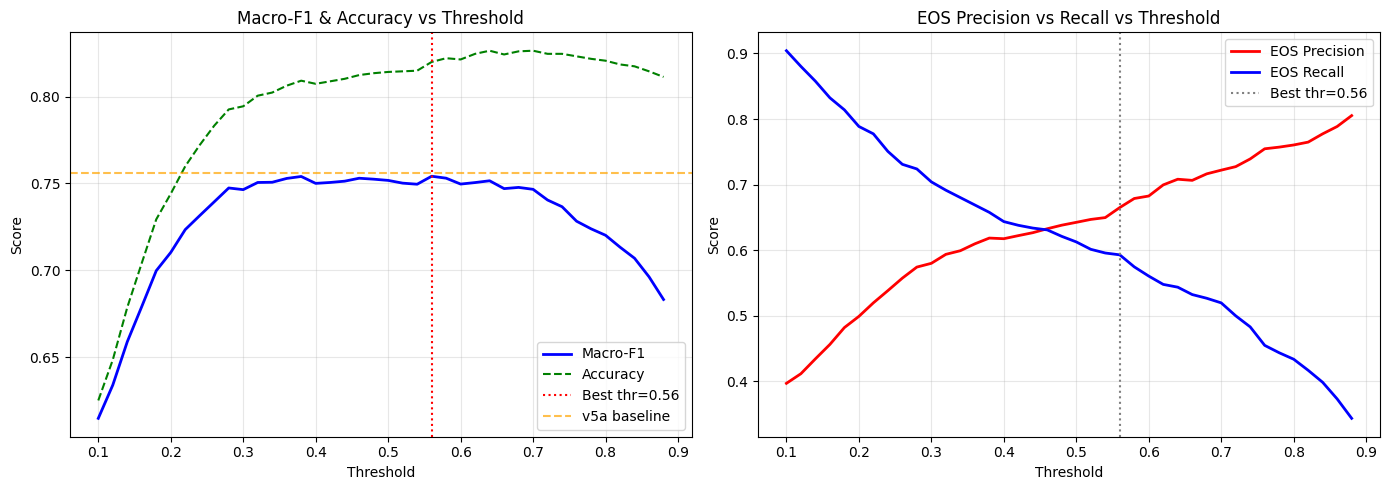

Saved: results/v6_threshold_sweep.png


In [16]:
# E7b — Threshold sweep visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thr_df['Threshold'], thr_df['Macro-F1'], 'b-', label='Macro-F1', linewidth=2)
axes[0].plot(thr_df['Threshold'], thr_df['Accuracy'], 'g--', label='Accuracy')
axes[0].axvline(x=best_threshold, color='r', linestyle=':', label=f'Best thr={best_threshold:.2f}')
axes[0].axhline(y=0.7559, color='orange', linestyle='--', alpha=0.7, label='v5a baseline')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Macro-F1 & Accuracy vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(thr_df['Threshold'], thr_df['EOS-Prec'], 'r-', label='EOS Precision', linewidth=2)
axes[1].plot(thr_df['Threshold'], thr_df['EOS-Rec'], 'b-', label='EOS Recall', linewidth=2)
axes[1].axvline(x=best_threshold, color='gray', linestyle=':', label=f'Best thr={best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('EOS Precision vs Recall vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_threshold_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/v6_threshold_sweep.png')

---
## §FINAL — Comprehensive Leaderboard & Decision
Compare all experiments against v5a baseline. Pick the best or fall back.

In [ ]:
# Final leaderboard — remove old invalid E6 entries (before dedup fix)
INVALID_E6 = [
    'E6: Text+Struct+SMOTE+RF',
    'E6: Text+Struct+BalancedRF',
    'E6: Text-only control (same split)',
]
leaderboard_clean = [r for r in leaderboard if r['Model'] not in INVALID_E6]
lb_final = pd.DataFrame(leaderboard_clean).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
lb_final.index = lb_final.index + 1
lb_final.index.name = 'Rank'

print("\n" + "="*80)
print("  LEADERBOARD (sorted by Macro-F1) — invalid E6 entries removed")
print("="*80)
print(lb_final.to_string())

# Highlight improvements over v5a
baseline_mf1 = V5A_BASELINE['Macro-F1']
lb_final['Δ Macro-F1'] = (lb_final['Macro-F1'] - baseline_mf1).round(4)
lb_final['Improved?'] = lb_final['Δ Macro-F1'].apply(lambda x: '✅ YES' if x > 0 else ('➖ SAME' if x == 0 else '❌ NO'))

print('\n' + '='*90)
print('  FINAL COMPARISON vs v5a BASELINE (Macro-F1=0.7559)')
print('='*90)
print(lb_final[['Model', 'Macro-F1', 'Δ Macro-F1', 'Accuracy', 'EOS-Prec', 'EOS-Rec', 'Improved?']].to_string())

# Decision
best_overall = lb_final.iloc[0]
print(f'\n{"="*60}')
if best_overall['Model'] == 'v5a RF-SMOTE (baseline)':
    print('  DECISION: No improvement found. KEEPING v5a baseline.')
    print('  → Fall back to v5a RF-SMOTE (Macro-F1=0.7559)')
else:
    print(f'  DECISION: Best model is {best_overall["Model"]}')
    print(f'  → Macro-F1: {best_overall["Macro-F1"]:.4f} (Δ={best_overall["Δ Macro-F1"]:+.4f})')
    print(f'  → Accuracy: {best_overall["Accuracy"]:.4f}')
    print(f'  → EOS-Prec: {best_overall["EOS-Prec"]:.4f}, EOS-Rec: {best_overall["EOS-Rec"]:.4f}')
print('='*60)


  LEADERBOARD (sorted by Macro-F1)
                                         Model  Macro-F1  Accuracy  EOS-Prec  EOS-Rec  EOS-F1  Time(s)  Features  Train size
Rank                                                                                                                        
1                     E6: Text+Struct+SMOTE+RF    0.8939    0.9507    0.8147   0.8181  0.8164      NaN       NaN         NaN
2           E6: Text-only control (same split)    0.8726    0.9374    0.7334   0.8368  0.7817      NaN       NaN         NaN
3                   E6: Text+Struct+BalancedRF    0.8559    0.9208    0.6401   0.9326  0.7592      NaN       NaN         NaN
4                    E1: TF-IDF word_plus_char    0.7705    0.8325    0.6949   0.6127  0.6512     23.7    6000.0         NaN
5      E5: Translated+WordChar TF-IDF+SMOTE+RF    0.7685    0.8311    0.6917   0.6099  0.6482      NaN       NaN         NaN
6                       E1: TF-IDF char_wb_3_5    0.7604    0.8231    0.6682   0.6099  0.

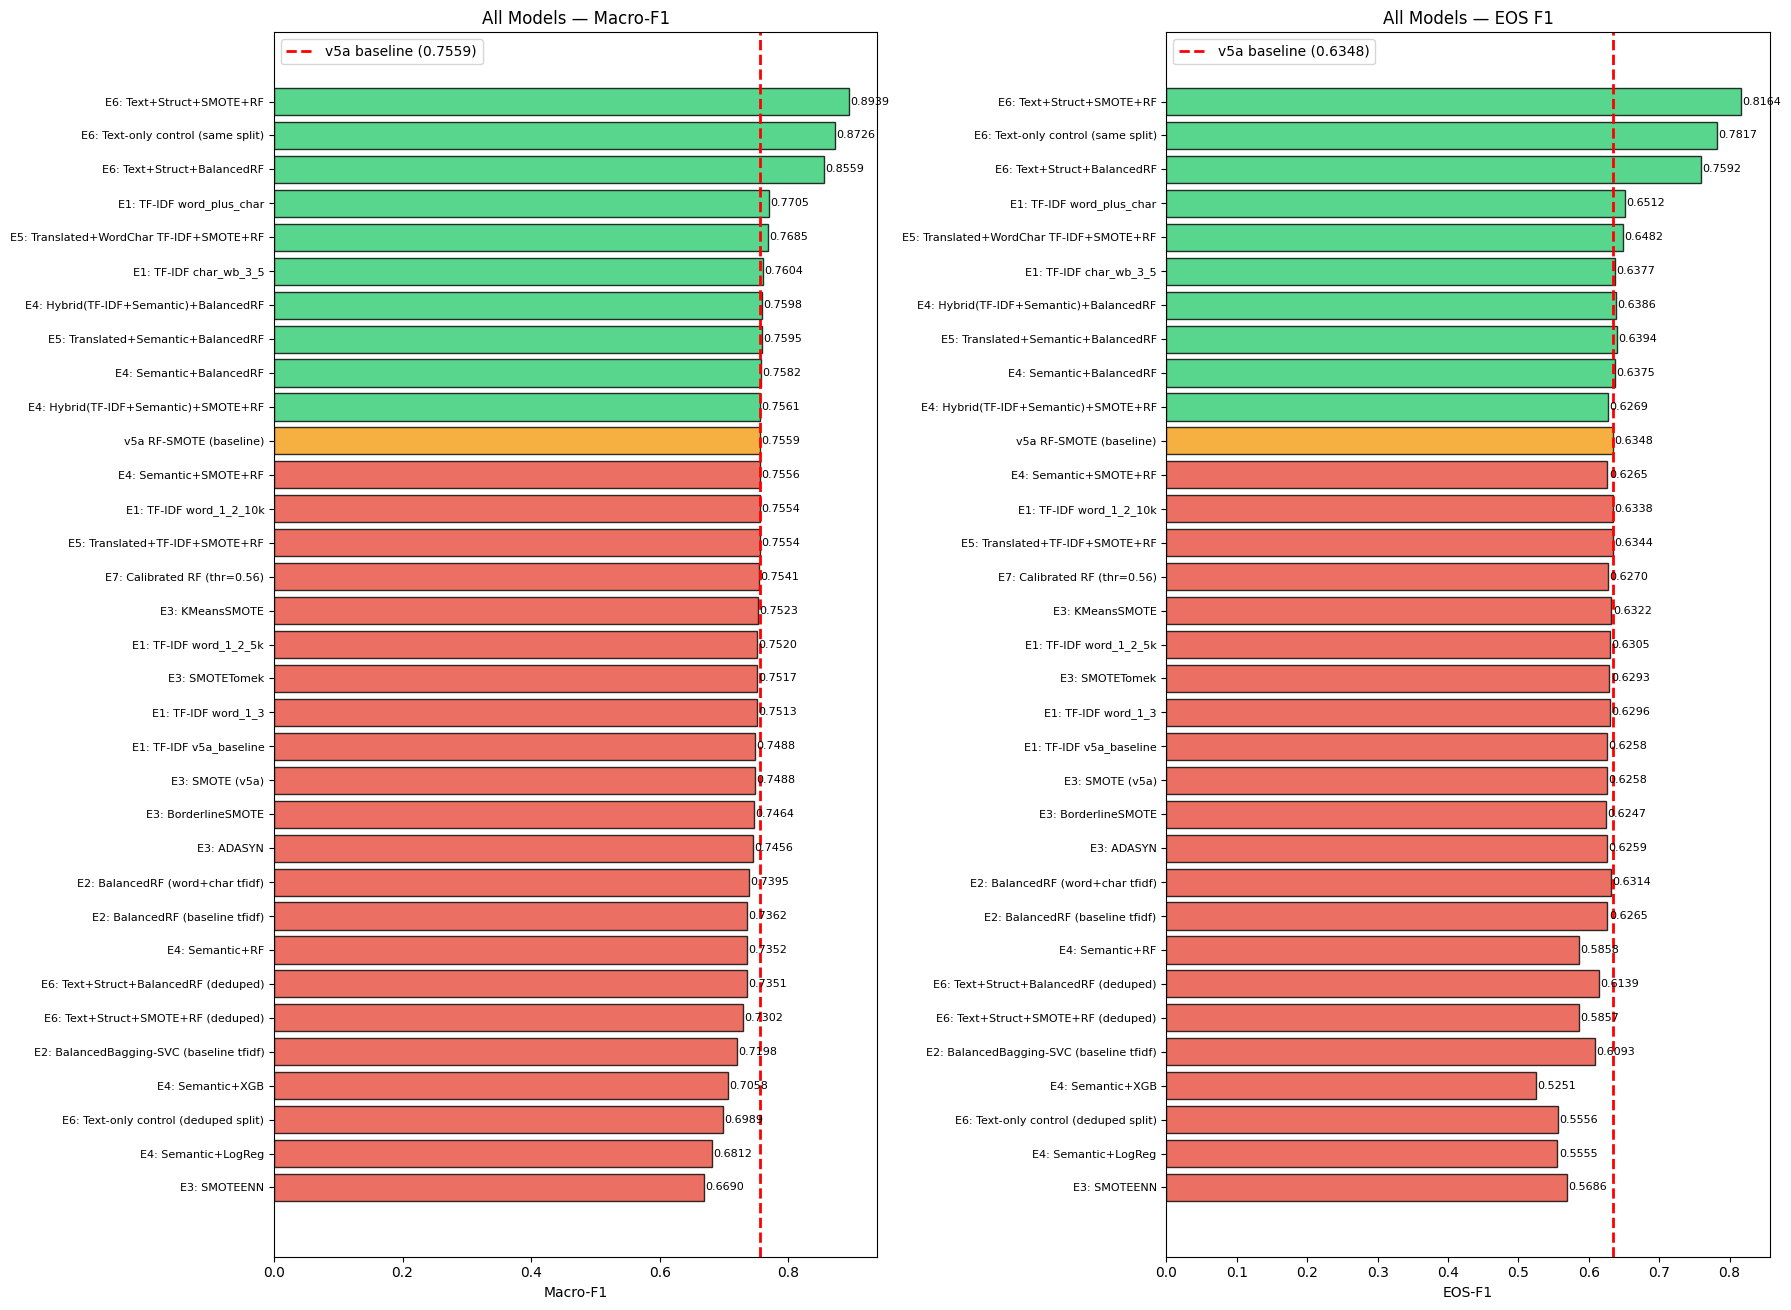

Saved: results/v6_all_models_comparison.png


In [23]:
# Visualization: bar chart comparing all models
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(lb_final)*0.4)))

# Sort by Macro-F1
lb_plot = lb_final.sort_values('Macro-F1', ascending=True)
colors = ['#2ecc71' if x > 0 else ('#f39c12' if x == 0 else '#e74c3c') for x in lb_plot['Δ Macro-F1']]

axes[0].barh(range(len(lb_plot)), lb_plot['Macro-F1'], color=colors, edgecolor='black', alpha=0.8)
axes[0].axvline(x=baseline_mf1, color='red', linestyle='--', linewidth=2, label=f'v5a baseline ({baseline_mf1})')
axes[0].set_yticks(range(len(lb_plot)))
axes[0].set_yticklabels(lb_plot['Model'], fontsize=8)
axes[0].set_xlabel('Macro-F1')
axes[0].set_title('All Models — Macro-F1')
axes[0].legend()
for i, v in enumerate(lb_plot['Macro-F1']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

# EOS F1 comparison
axes[1].barh(range(len(lb_plot)), lb_plot['EOS-F1'], color=colors, edgecolor='black', alpha=0.8)
axes[1].axvline(x=V5A_BASELINE['EOS-F1'], color='red', linestyle='--', linewidth=2, label=f'v5a baseline ({V5A_BASELINE["EOS-F1"]})')
axes[1].set_yticks(range(len(lb_plot)))
axes[1].set_yticklabels(lb_plot['Model'], fontsize=8)
axes[1].set_xlabel('EOS-F1')
axes[1].set_title('All Models — EOS F1')
axes[1].legend()
for i, v in enumerate(lb_plot['EOS-F1']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_all_models_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/v6_all_models_comparison.png')

In [24]:
# Save results CSV
lb_final.to_csv(os.path.join(RESULTS_DIR, 'v6_all_results.csv'), index=False)
print(f'Saved: results/v6_all_results.csv')

# Save best model artifacts if it beats v5a
if best_overall['Model'] != 'v5a RF-SMOTE (baseline)' and best_overall['Macro-F1'] > baseline_mf1:
    print(f'\nSaving best v6 model artifacts to {MODELS_DIR} ...')
    
    metadata = {
        'version': 'v6',
        'best_model': best_overall['Model'],
        'macro_f1': float(best_overall['Macro-F1']),
        'accuracy': float(best_overall['Accuracy']),
        'eos_precision': float(best_overall['EOS-Prec']),
        'eos_recall': float(best_overall['EOS-Rec']),
        'eos_f1': float(best_overall['EOS-F1']),
        'delta_macro_f1_vs_v5a': float(best_overall['Δ Macro-F1']),
        'v5a_baseline_macro_f1': baseline_mf1,
        'decision': 'v6 model adopted',
    }
    
    with open(os.path.join(MODELS_DIR, 'metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f'  Saved metadata.json')
    print(f'  NOTE: Model-specific artifacts depend on winning experiment.')
    print(f'        Re-run the winning experiment\'s save cell to persist artifacts.')
else:
    metadata = {
        'version': 'v6',
        'decision': 'fallback to v5a',
        'reason': 'no v6 experiment improved over v5a baseline',
        'v5a_baseline_macro_f1': baseline_mf1,
        'best_v6_model': best_overall['Model'] if best_overall['Model'] != 'v5a RF-SMOTE (baseline)' else None,
        'best_v6_macro_f1': float(best_overall['Macro-F1']) if best_overall['Model'] != 'v5a RF-SMOTE (baseline)' else None,
    }
    with open(os.path.join(MODELS_DIR, 'metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f'\nNo improvement over v5a. Falling back to v5a baseline.')
    print(f'Saved fallback metadata to {MODELS_DIR}/metadata.json')

print('\n✅ v6 experiment notebook complete.')

Saved: results/v6_all_results.csv

Saving best v6 model artifacts to <project-root> ...
  Saved metadata.json
  NOTE: Model-specific artifacts depend on winning experiment.
        Re-run the winning experiment's save cell to persist artifacts.

✅ v6 experiment notebook complete.
